In [1]:
# Cel (22.08.2026, na prosbe Maćka): rozszerzenie "globalnej heatmapy sily
# efektu" z 20260820b.ipynb (komorka 3 - ta, ktora pokazala klaster
# 2006-2009 jako pionowy pas wspolny dla wielu stacji) na PELNA historie
# (1965-2020, nie tylko 2005-2015) - Maciek patrzac na wykres fazy z
# 20260822e.ipynb odniosl wrazenie, ze klastry moga miec jakas
# periodycznosc, ktora warto zobaczyc bezposrednio na surowej krzywej
# PPDF-vs-t0, nie tylko przez pryzmat ekstremow per segment.
#
# ZERO nowych obliczen NMDB/skanu - to samo zrodlo danych co
# 20260822e.ipynb (results/cycle_scan_*.csv, PELNE krzywe PPDF-vs-t0 per
# kandydat), tylko inny sposob wizualizacji (2D heatmapa zamiast
# segmentowych ekstremow).
#
# Roznica wzgledem 20260820b.ipynb: tam wszystkie stacje mialy IDENTYCZNY
# t0_candidates (jedna wspolna tablica, bo skan byl robiony na wspolnym
# zakresie 2005-2015). Tutaj stacje maja RUZNE zakresy dat (rozna glebokosc
# historii) - wiec budujemy WSPOLNA os czasu (dzienny krok, jak T0_STEP=24h
# w 20260822c.ipynb) i kazda stacje reindeksujemy na nia, z NaN tam gdzie
# dana stacja nie ma jeszcze/juz danych (naturalnie odwzorowuje "od
# poczatku dzialania stacji").
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import find_peaks
from statsmodels.nonparametric.smoothers_lowess import lowess

RESULTS_DIR = "../results"
HOMOLA_LOG10_PPDF_BENCHMARK = -8

STATION_NAMES = sorted(
    ["mosc", "oulu", "athn", "hrms", "sopb", "thul", "lmks", "apty", "jung1",
     "sopo", "fsmt", "jung", "newk", "pwnk", "mxco", "nain", "tera", "invk",
     "aatb", "psnm", "nanm", "mcrl"],
    key=len, reverse=True,
)
FILENAME_RE = re.compile(r"^(?P<cycle>cycle_\d{4}(?:_incomplete)?)_P(?P<Pdays>\d+)_d(?P<d>\d+)$")


def parse_result_filename(path):
    base = os.path.basename(path)
    if not (base.startswith("cycle_scan_") and base.endswith(".csv")):
        return None
    rest = base[len("cycle_scan_"):-len(".csv")]
    station = next((s for s in STATION_NAMES if rest.startswith(s + "_")), None)
    if station is None:
        return None
    m = FILENAME_RE.match(rest[len(station) + 1:])
    if not m:
        return None
    return dict(station=station, P_days=int(m["Pdays"]), d=int(m["d"]))


frames = []
for path in sorted(glob.glob(os.path.join(RESULTS_DIR, "cycle_scan_*.csv"))):
    meta = parse_result_filename(path)
    if meta is None:
        continue
    df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    if len(df) == 0:
        continue
    df["station"] = meta["station"]
    df["P_days"] = meta["P_days"]
    df["d"] = meta["d"]
    frames.append(df)

all_candidates = pd.concat(frames, ignore_index=True)
print(f"Wczytano {len(all_candidates)} wierszy z {len(frames)} plikow")


Wczytano 1206908 wierszy z 384 plikow


In [2]:
# Minima (przejscia/granice oryginalnego cyklu) i maksima (granice
# przesunietego grupowania z 20260822e.ipynb) - do nakladek na heatmapy.
# Ta sama LOWESS (frac=0.01) co w 20260822c/e.ipynb.
sn = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sn.columns = [c.strip() for c in sn.columns]
sn["date"] = pd.to_datetime(dict(year=sn["rok"], month=sn["miesiac"], day=1))
smoothed = lowess(sn["sunspot"].values, sn["rok_norm"].values, frac=0.01)[:, 1]

min_idx, _ = find_peaks(-smoothed, distance=100, prominence=5)
max_idx, _ = find_peaks(smoothed, distance=100, prominence=5)
transition_dates = pd.to_datetime(sn["date"].values[min_idx])
shift_dates = pd.to_datetime(sn["date"].values[max_idx])

# Kolejnosc stacji na osi Y: wg roku pierwszego dostepnego kandydata t0
# (najdluzsza historia na gorze) - czytelniejsze niz alfabetycznie przy
# tylu roznych zakresach dat.
station_start = all_candidates.groupby("station")["t0"].min().sort_values()
STATIONS_ORDER = station_start.index.tolist()
print("Stacje wg dlugosci historii (najstarsza -> najmlodsza):")
for s in STATIONS_ORDER:
    print(f"  {s}: od {station_start[s].date()}")


Stacje wg dlugosci historii (najstarsza -> najmlodsza):
  aatb: od 1965-01-02
  sopo: od 1965-01-02
  oulu: od 1965-01-02
  newk: od 1965-01-02
  tera: od 1965-01-02
  jung: od 1965-01-02
  mosc: od 1965-01-02
  hrms: od 1965-01-02
  thul: od 1965-01-02
  lmks: od 1972-10-02
  jung1: od 1976-11-02
  mxco: od 1980-11-02
  nanm: od 1987-11-03
  sopb: od 1990-11-02
  invk: od 1990-11-02
  apty: od 1991-05-03
  pwnk: od 1991-07-17
  fsmt: od 1991-08-06
  nain: od 1991-09-12
  athn: od 1991-09-12
  psnm: od 1998-10-10
  mcrl: od 1999-07-25


In [3]:
# Budowa macierzy heatmapy: wspolna, dzienna os czasu (jak T0_STEP=24h w
# 20260822c.ipynb) + reindeksacja kazdej stacji na nia (NaN tam gdzie stacja
# nie ma jeszcze/juz danych - imshow rysuje to jako biale/puste pole,
# naturalnie pokazujac "od poczatku dzialania stacji").
def build_heatmap_matrix(P_days, d, stations_order=STATIONS_ORDER):
    sub_all = all_candidates[(all_candidates["P_days"] == P_days) & (all_candidates["d"] == d)]
    t0_ref = pd.date_range(sub_all["t0"].min(), sub_all["t0"].max(), freq="24h")
    mat = np.full((len(stations_order), len(t0_ref)), np.nan)
    for i, station in enumerate(stations_order):
        sub = sub_all[sub_all["station"] == station].drop_duplicates("t0").set_index("t0")
        ppdf = sub["PPDF"].reindex(t0_ref).to_numpy(dtype=float)
        with np.errstate(divide="ignore"):
            mat[i] = -np.log10(np.clip(ppdf, 1e-300, None))
    return t0_ref, mat


def plot_heatmap(P_days, d, overlay="transitions", title_suffix="", save_suffix=""):
    t0_ref, mat = build_heatmap_matrix(P_days, d)
    fig, ax = plt.subplots(figsize=(18, 9))
    im = ax.imshow(
        mat, aspect="auto", cmap="viridis",
        extent=[mdates.date2num(t0_ref[0]), mdates.date2num(t0_ref[-1]), len(STATIONS_ORDER) - 0.5, -0.5],
    )
    ax.xaxis_date()
    ax.set_yticks(range(len(STATIONS_ORDER)))
    ax.set_yticklabels(STATIONS_ORDER)
    for i in range(1, len(STATIONS_ORDER)):
        ax.axhline(i - 0.5, color="white", lw=0.6, alpha=0.7)
    ax.set_ylim(len(STATIONS_ORDER) - 0.5, -0.5)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("-log10(PPDF)")

    if overlay in ("transitions", "both"):
        for td in transition_dates:
            if t0_ref.min() <= td <= t0_ref.max():
                ax.axvline(td, color="red", ls="--", lw=1.0, alpha=0.8)
    if overlay in ("shifted", "both"):
        for sd in shift_dates:
            if t0_ref.min() <= sd <= t0_ref.max():
                ax.axvline(sd, color="cyan", ls="--", lw=1.0, alpha=0.8)
    if overlay == "decades":
        for year in range(1960, 2026, 10):
            dt = pd.Timestamp(f"{year}-01-01")
            if t0_ref.min() <= dt <= t0_ref.max():
                ax.axvline(dt, color="red", ls="--", lw=1.0, alpha=0.8)
                ax.text(dt, -1.3, str(year), color="red", fontsize=9, ha="center")

    ax.set_xlabel("t0")
    ax.set_title(f"Globalna heatmapa siły efektu (P_days={P_days}, d={d}){title_suffix}")
    fig.tight_layout()
    if save_suffix:
        fig.savefig(f"{RESULTS_DIR}/cycle_scan_fullhistory_heatmap_{save_suffix}.png", dpi=120)
    plt.show()


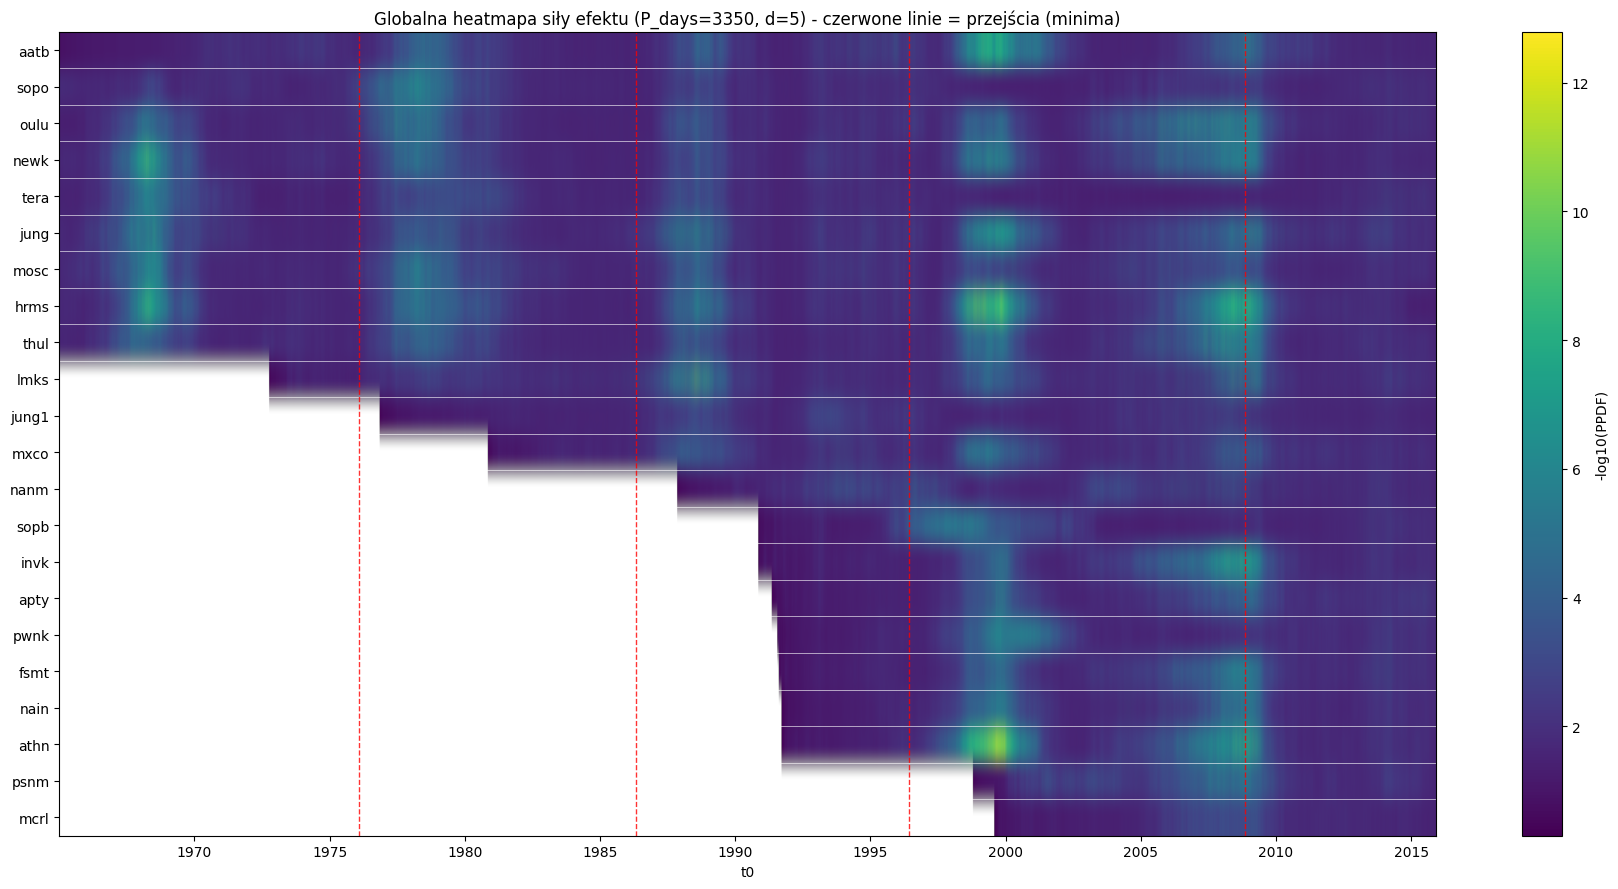

In [4]:
# WERSJA 1: P_days=3350, d=5 (kombinacja z najwiecej trafien) - nakladka
# CZERWONA = oryginalne przejscia (minima sloneczne, granice cykli).
plot_heatmap(3350, 5, overlay="transitions",
             title_suffix=" - czerwone linie = przejścia (minima)", save_suffix="d5_transitions")


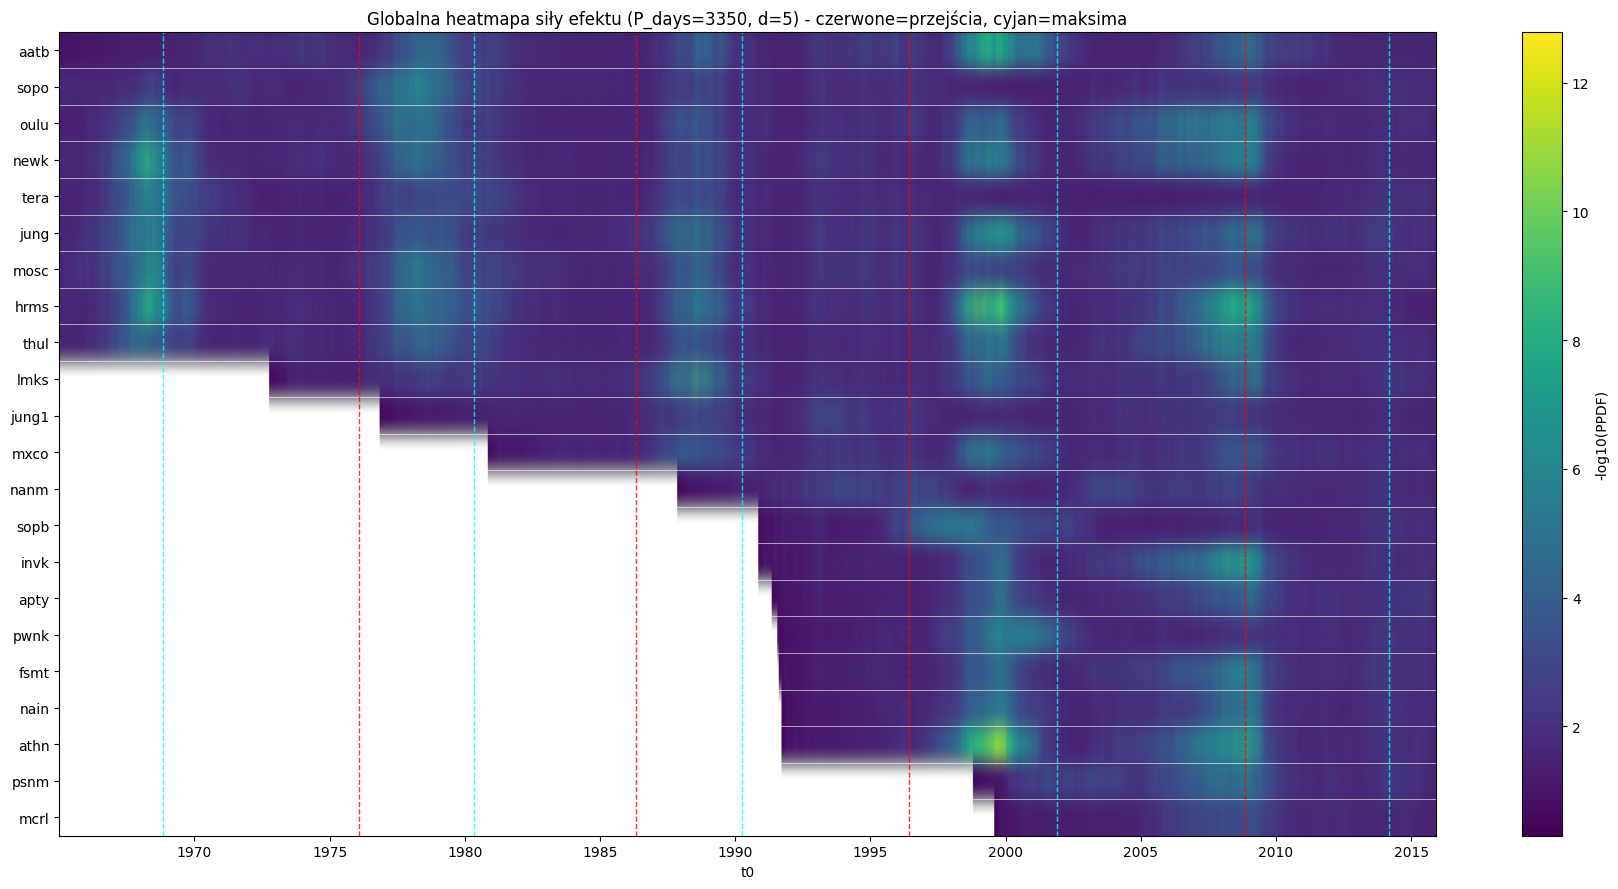

In [5]:
# WERSJA 2: to samo, ale z OBIEMA nakladkami naraz - CZERWONA = przejscia
# (minima), CYJAN = maksima (granice przesunietego grupowania z
# 20260822e.ipynb) - zeby wprost porownac, czy pasy sily efektu leza blizej
# czerwonych czy niebieskich linii.
plot_heatmap(3350, 5, overlay="both",
             title_suffix=" - czerwone=przejścia, cyjan=maksima", save_suffix="d5_both")


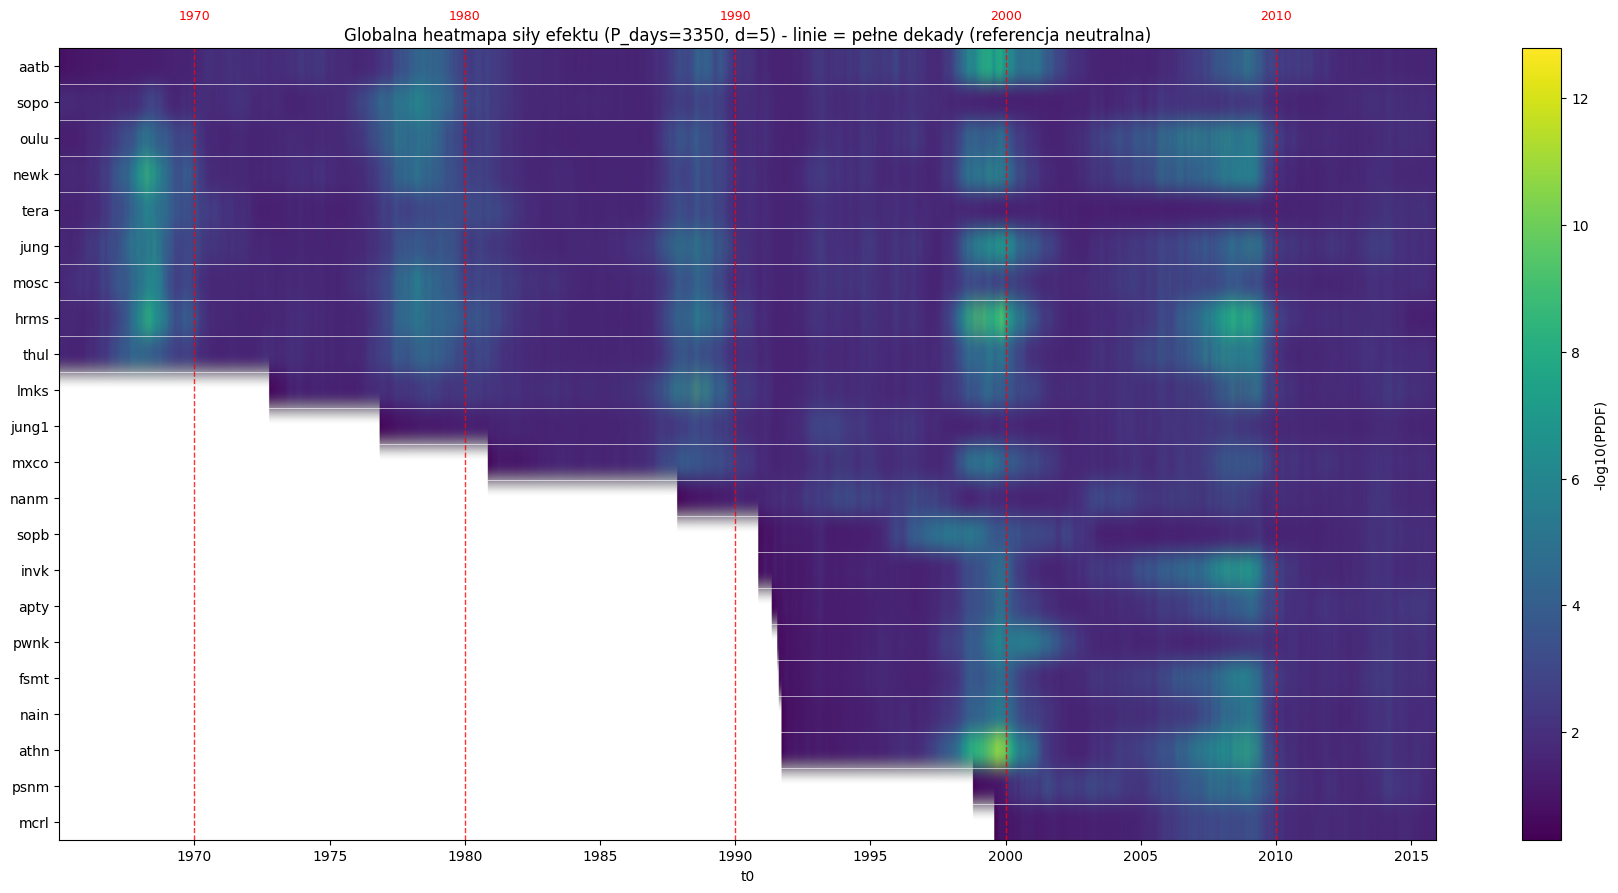

In [6]:
# WERSJA 3: neutralne dekady (bez zadnej hipotezy o cyklach slonecznych) -
# zeby zobaczyc, czy periodycznosc (jesli jest) wyglada bardziej na ~11 lat
# (cykl sloneczny) czy na cos innego (np. rowne dekady, co byloby podejrzane
# - sugerowaloby artefakt kalendarzowy/danych, nie fizyke).
plot_heatmap(3350, 5, overlay="decades",
             title_suffix=" - linie = pełne dekady (referencja neutralna)", save_suffix="d5_decades")


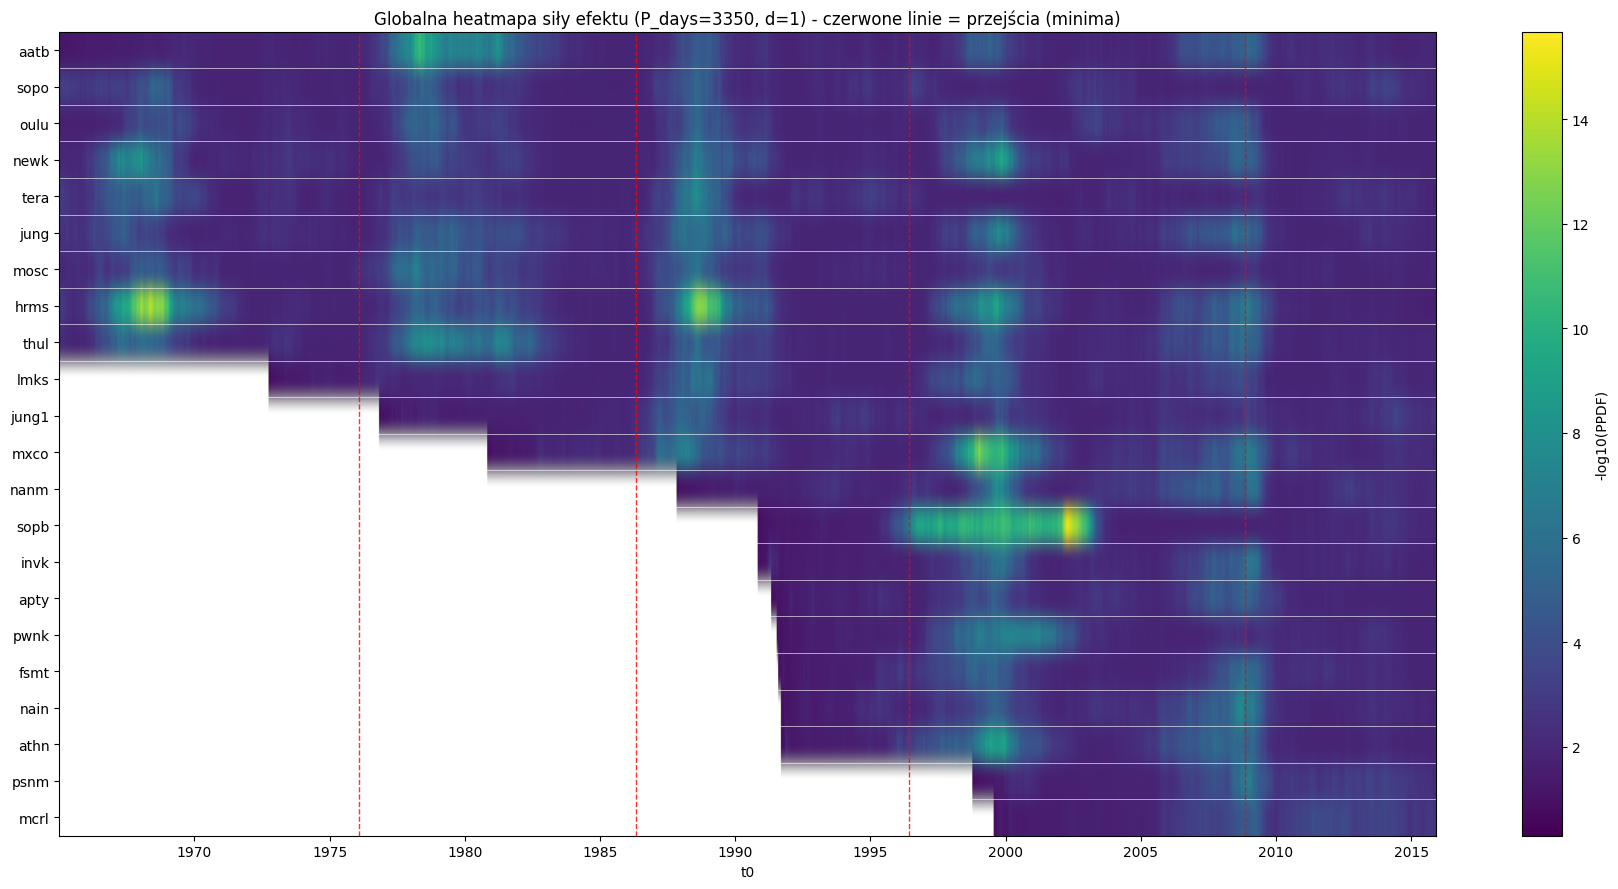

In [7]:
# WERSJA 4: d=1 zamiast d=5 (P_days=3350) - kontrola, czy ten sam wzorzec
# widac przy innej szerokosci binu.
plot_heatmap(3350, 1, overlay="transitions",
             title_suffix=" - czerwone linie = przejścia (minima)", save_suffix="d1_transitions")


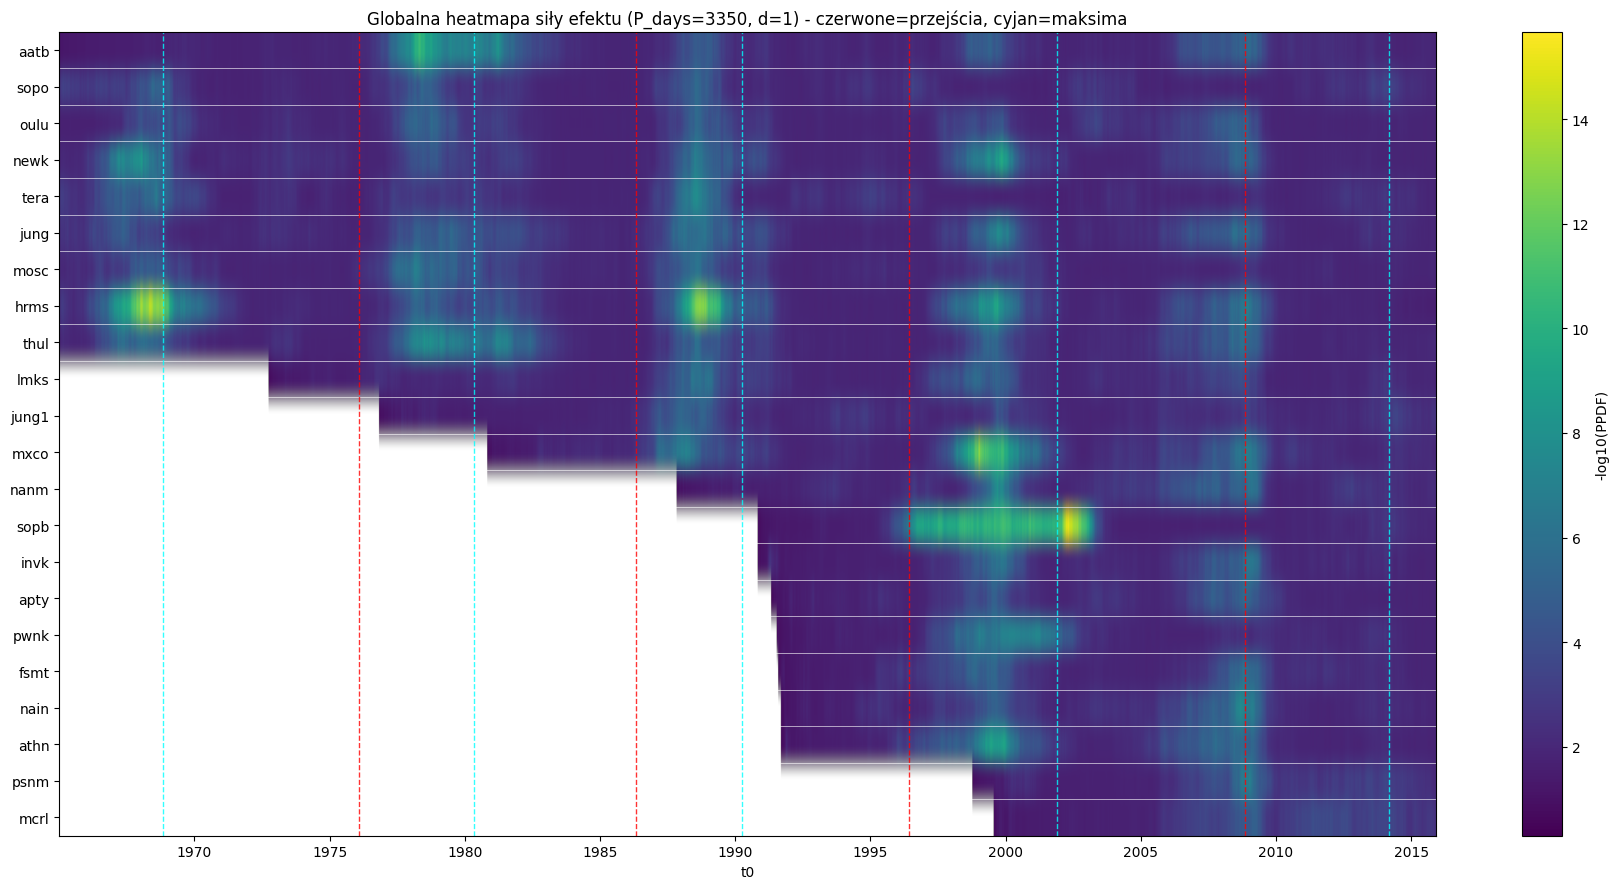

In [8]:
# WERSJA 5: d=1 z OBIEMA nakladkami naraz (jak WERSJA 2, ale kontrola przy
# innej szerokosci binu) - na prosbe Maćka, zeby zobaczyc na tym samym
# wykresie zarowno minima jak i maksima i ocenic wizualnie, czy klastry
# grupuja sie MIEDZY nimi (faza wzrostu aktywnosci slonecznej).
plot_heatmap(3350, 1, overlay="both",
             title_suffix=" - czerwone=przejścia, cyjan=maksima", save_suffix="d1_both")


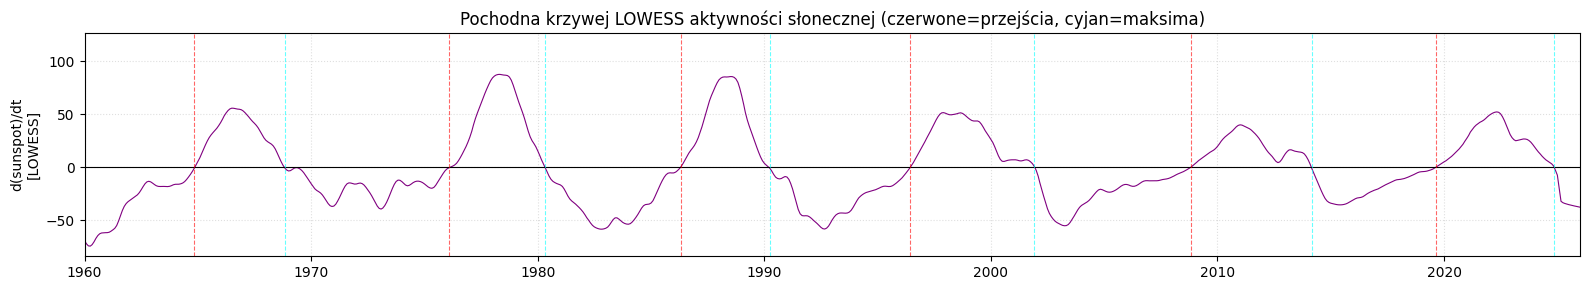

In [9]:
# Test hipotezy Maćka: czy silne wyniki PPDF pojawiaja sie w fazie WZROSTU
# aktywnosci slonecznej (miedzy minimum a maksimum), czyli gdy POCHODNA
# krzywej LOWESS jest DODATNIA i duza - nie w samym minimum/maksimum.
#
# Pochodna liczona jako np.gradient krzywej LOWESS (miesieczna rozdzielczosc
# SN_m_tot_V2.0.csv) po rok_norm - jednostki: liczba plam slonecznych/rok.
# ZASTRZEZENIE (wprost od Maćka): LOWESS to przyblizenie zachowania Slonca,
# nie "prawdziwa" fizyczna pochodna - ale rozsadny pierwszy strzal, dopoki
# nie mamy nic lepszego. Interpolacja liniowa na dzienne daty t0 kandydatow
# (LOWESS/pochodna sa miesieczne, kandydaci dzienni).
sn_derivative = np.gradient(smoothed, sn["rok_norm"].values)


def solar_derivative_at(dates):
    x = mdates.date2num(sn["date"].to_numpy())
    return np.interp(mdates.date2num(pd.DatetimeIndex(dates)), x, sn_derivative)


fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(sn["date"], sn_derivative, color="purple", lw=0.8)
ax.axhline(0, color="black", lw=0.8)
for td in transition_dates:
    ax.axvline(td, color="red", ls="--", lw=0.8, alpha=0.6)
for sd in shift_dates:
    ax.axvline(sd, color="cyan", ls="--", lw=0.8, alpha=0.6)
ax.set_xlim(pd.Timestamp("1960-01-01"), pd.Timestamp("2026-01-01"))
ax.set_ylabel("d(sunspot)/dt\n[LOWESS]")
ax.set_title("Pochodna krzywej LOWESS aktywności słonecznej (czerwone=przejścia, cyjan=maksima)")
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
plt.show()


In [10]:
# Korelacja pochodnej LOWESS (w t0 kandydata) z sila efektu (-log10 PPDF)
# per stacja/P_days/d. Hipoteza Maćka przewiduje korelacje DODATNIA
# (rosnaca aktywnosc sloneczna -> silniejszy efekt). Spearman (odpornosc na
# skrajne wartosci PPDF, nie zaklada liniowosci) jako glowna miara,
# Pearson dla porownania. Dodatkowo korelacja z WARTOSCIA BEZWZGLEDNA
# pochodnej (|d(sunspot)/dt|) - odroznia hipoteze "konkretnie wzrost"
# (Maciek) od hipotezy "jakakolwiek szybka zmiana, kierunek bez znaczenia".
from scipy.stats import spearmanr, pearsonr

rows = []
for (station, P_days, d), g in all_candidates.groupby(["station", "P_days", "d"]):
    if len(g) < 30:
        continue
    strength = -np.log10(np.clip(g["PPDF"].to_numpy(dtype=float), 1e-300, None))
    deriv = solar_derivative_at(g["t0"].to_numpy())
    rho, p_spear = spearmanr(deriv, strength)
    r, p_pear = pearsonr(deriv, strength)
    rho_abs, p_spear_abs = spearmanr(np.abs(deriv), strength)
    rows.append(dict(
        station=station, P_days=P_days, d=d, n=len(g),
        spearman_rho=rho, spearman_p=p_spear,
        pearson_r=r, pearson_p=p_pear,
        spearman_rho_abs_deriv=rho_abs, spearman_p_abs_deriv=p_spear_abs,
    ))

corr_df = pd.DataFrame(rows).sort_values("spearman_rho", ascending=False)
pd.set_option("display.width", 200)
print(corr_df.to_string(index=False))
corr_df.to_csv(f"{RESULTS_DIR}/cycle_scan_solar_derivative_correlation.csv", index=False)

print("\nPodsumowanie (P_days=3350, d=5 - kombinacja z najwiecej trafien):")
sub = corr_df[(corr_df["P_days"] == 3350) & (corr_df["d"] == 5)]
print(f"  mediana spearman_rho (pochodna sygnowana): {sub['spearman_rho'].median():.3f}")
print(f"  mediana spearman_rho (|pochodna|): {sub['spearman_rho_abs_deriv'].median():.3f}")
print(f"  stacje z istotna dodatnia korelacja (p<0.05, rho>0): {(sub['spearman_p'].lt(0.05) & sub['spearman_rho'].gt(0)).sum()}/{len(sub)}")


station  P_days  d     n  spearman_rho    spearman_p  pearson_r     pearson_p  spearman_rho_abs_deriv  spearman_p_abs_deriv
   fsmt    3350  1  8885      0.784625  0.000000e+00   0.633757  0.000000e+00               -0.339550         1.269178e-238
   mxco    3350  1 12815      0.629843  0.000000e+00   0.596743  0.000000e+00               -0.111977          4.887467e-37
   pwnk    3350  1  8905      0.627898  0.000000e+00   0.517960  0.000000e+00               -0.120558          3.452839e-30
   athn    3350  1  8848      0.565700  0.000000e+00   0.532332  0.000000e+00               -0.372450         3.189470e-289
   sopb    3350  5  9154      0.563860  0.000000e+00   0.606918  0.000000e+00               -0.075201          5.837243e-13
   pwnk    3350  5  8897      0.560245  0.000000e+00   0.468175  0.000000e+00               -0.169993          1.138379e-58
   mosc    3350  1 18599      0.545479  0.000000e+00   0.638832  0.000000e+00                0.140521          1.202800e-82
   mxco 

In [ ]:
# Wizualizacja: (a) bar chart spearman_rho (pochodna sygnowana) per
# stacja, d=1 vs d=5 obok siebie - funkcja wielokrotnego uzytku (wywolana
# tutaj dla P_days=3350, w kolejnej komorce dla P_days=1675 - do
# bezposredniego porownania, ktore pokazuje ze wzorzec "psuje sie" przy
# P=1675); (b) scatter pochodna-vs-sila dla 2 stacji o najsilniejszej
# korelacji przy P=3350 (wizualna kontrola, czy to realny trend czy
# artefakt paru punktow).
def plot_derivative_correlation_barplot(P_days, save_suffix):
    pivot_corr = corr_df[corr_df["P_days"] == P_days].pivot(index="station", columns="d", values="spearman_rho")
    pivot_corr = pivot_corr.reindex(pivot_corr.mean(axis=1).sort_values(ascending=False).index)

    fig, ax = plt.subplots(figsize=(10, 8))
    y = np.arange(len(pivot_corr))
    width = 0.35
    for i, d in enumerate(sorted(pivot_corr.columns)):
        ax.barh(y + (i - 0.5) * width, pivot_corr[d], height=width, label=f"d={d}")
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(pivot_corr.index)
    ax.set_xlim(-0.6, 0.85)
    ax.set_xlabel("Spearman rho (pochodna LOWESS vs -log10(PPDF))")
    ax.set_title(f"Korelacja siły efektu z pochodną aktywności słonecznej, per stacja (P_days={P_days})")
    ax.legend()
    ax.grid(ls=":", alpha=0.5, axis="x")
    fig.tight_layout()
    fig.savefig(f"{RESULTS_DIR}/cycle_scan_solar_derivative_correlation_barplot_P{P_days}.png", dpi=120)
    plt.show()


plot_derivative_correlation_barplot(3350, "3350")

top_stations = corr_df[(corr_df["P_days"] == 3350) & (corr_df["d"] == 5)].nlargest(2, "spearman_rho")["station"].tolist()
fig, axes = plt.subplots(1, len(top_stations), figsize=(6 * len(top_stations), 5))
for ax, station in zip(np.atleast_1d(axes), top_stations):
    g = all_candidates[(all_candidates["station"] == station) & (all_candidates["P_days"] == 3350) & (all_candidates["d"] == 5)]
    strength = -np.log10(np.clip(g["PPDF"].to_numpy(dtype=float), 1e-300, None))
    deriv = solar_derivative_at(g["t0"].to_numpy())
    ax.scatter(deriv, strength, s=2, alpha=0.15)
    ax.set_xlabel("d(sunspot)/dt [LOWESS]")
    ax.set_ylabel("-log10(PPDF)")
    ax.set_title(f"{station} (P=3350, d=5)")
    ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/cycle_scan_solar_derivative_scatter_examples.png", dpi=120)
plt.show()


In [ ]:
# To samo dla P_days=1675 - ta sama skala osi X co powyzej (P=3350), zeby
# bezposrednio porownac. To ten wykres pokazuje "psucie sie" wyniku: brak
# spojnego kierunku, wiele stacji ujemnych, znacznie slabsze |rho|.
plot_derivative_correlation_barplot(1675, "1675")
